In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("experiment2/postprocessing/exp2_combined_data.csv")

In [3]:

test = len(df) == 13

# nRF against extra tiers

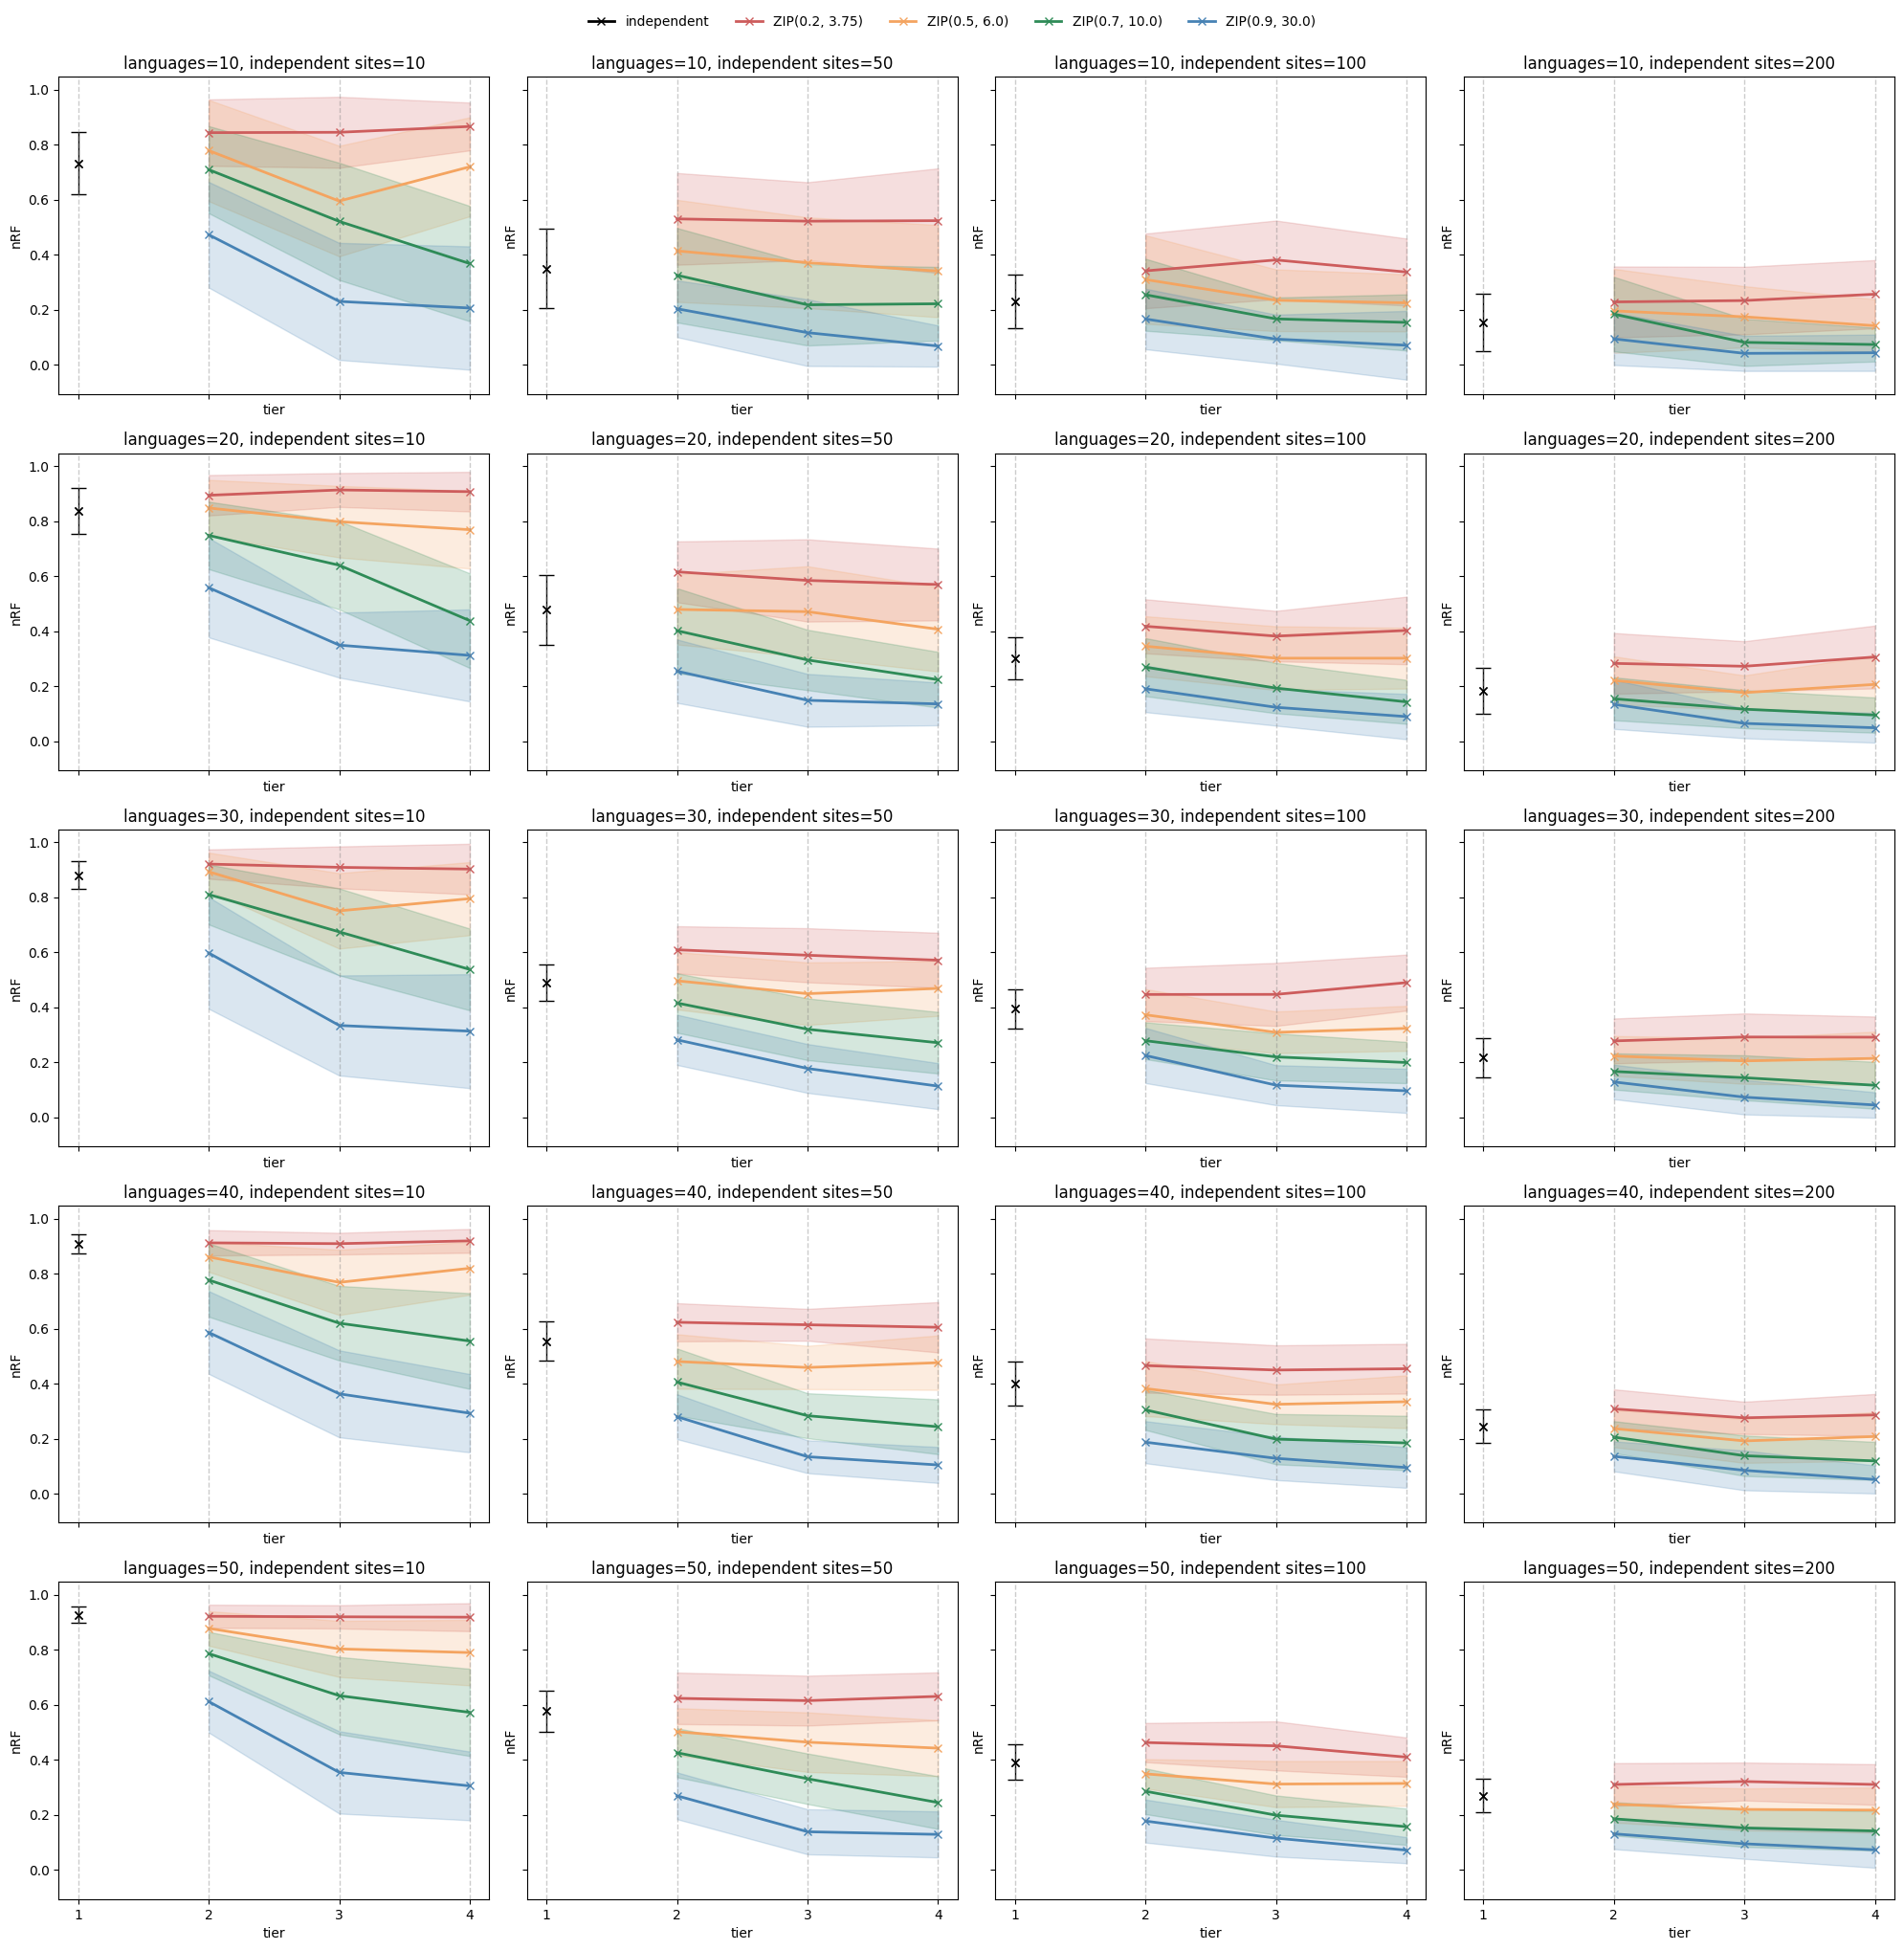

In [4]:
df["tier"] = pd.to_numeric(df["tier"])
df["meanNRF"] = pd.to_numeric(df["meanNRF"])
df["leaves"] = pd.to_numeric(df["leaves"])
df["independent_sites"] = pd.to_numeric(df["independent_sites"])

leaves_vals = sorted(df["leaves"].unique())
sites_vals = sorted(df["independent_sites"].unique())

fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

colors = ["black", "indianred", "sandybrown", "seagreen", "steelblue"]
for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):
        if test:
            ax = axes
        else:
            ax = axes[i, j]
        d = df[(df["leaves"] == leaves_val) & (df["independent_sites"] == sites_val)].copy()
        if d.empty:
            ax.set_visible(False)
            continue
        methods = d["ZIP"].unique()
        for k, m in enumerate(methods):
            dm = d[d["ZIP"] == m]
            grouped = dm.groupby("tier")["meanNRF"]
            mean = grouped.mean()
            std = grouped.std()
            x = mean.index.values
            color = colors[k]
            ax.plot(x, mean.values, marker="x", color=color, linewidth=2, label=m)
            if m == "independent":
                ax.errorbar(
                    x,
                    mean.values,
                    yerr=std.values,
                    fmt='x',
                    color=color,
                    linewidth=1,
                    capsize=6,
                    capthick=1,
                    label=m
                )
            else:
                ax.fill_between(
                    x,
                    mean - std,
                    mean + std,
                    color=color,
                    alpha=0.2
                )
        ax.set_title(f"languages={leaves_val}, independent sites={sites_val}")
        ax.set_xlabel("tier")
        ax.set_ylabel("nRF")
        ax.set_xticks([1, 2, 3, 4])
        for x in [1, 2, 3, 4]:
            ax.axvline(x, linestyle="--", linewidth=1, alpha=0.4, color="grey")
if test:
    handles, labels = axes.get_legend_handles_labels()
else:
    handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles[:-1],
    labels[:-1],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=5,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.tight_layout()
plt.show()

- Clearly more independent data is better from the plot (compare blue dots from left to right)
- But with more independent data adding tiers to the data is less useful (marginal improvement decreases?)
- In most cases, having more dependent data improves the model recovery
- Interestingly, generation needs to be extremely selective or extremely widespread - having ZIP(0.5, 6) actually nullifies the effect of more dependent tiers


make uninteresting plots
- plot amount of data that was created for each step

# Clade Recovery against extra tiers

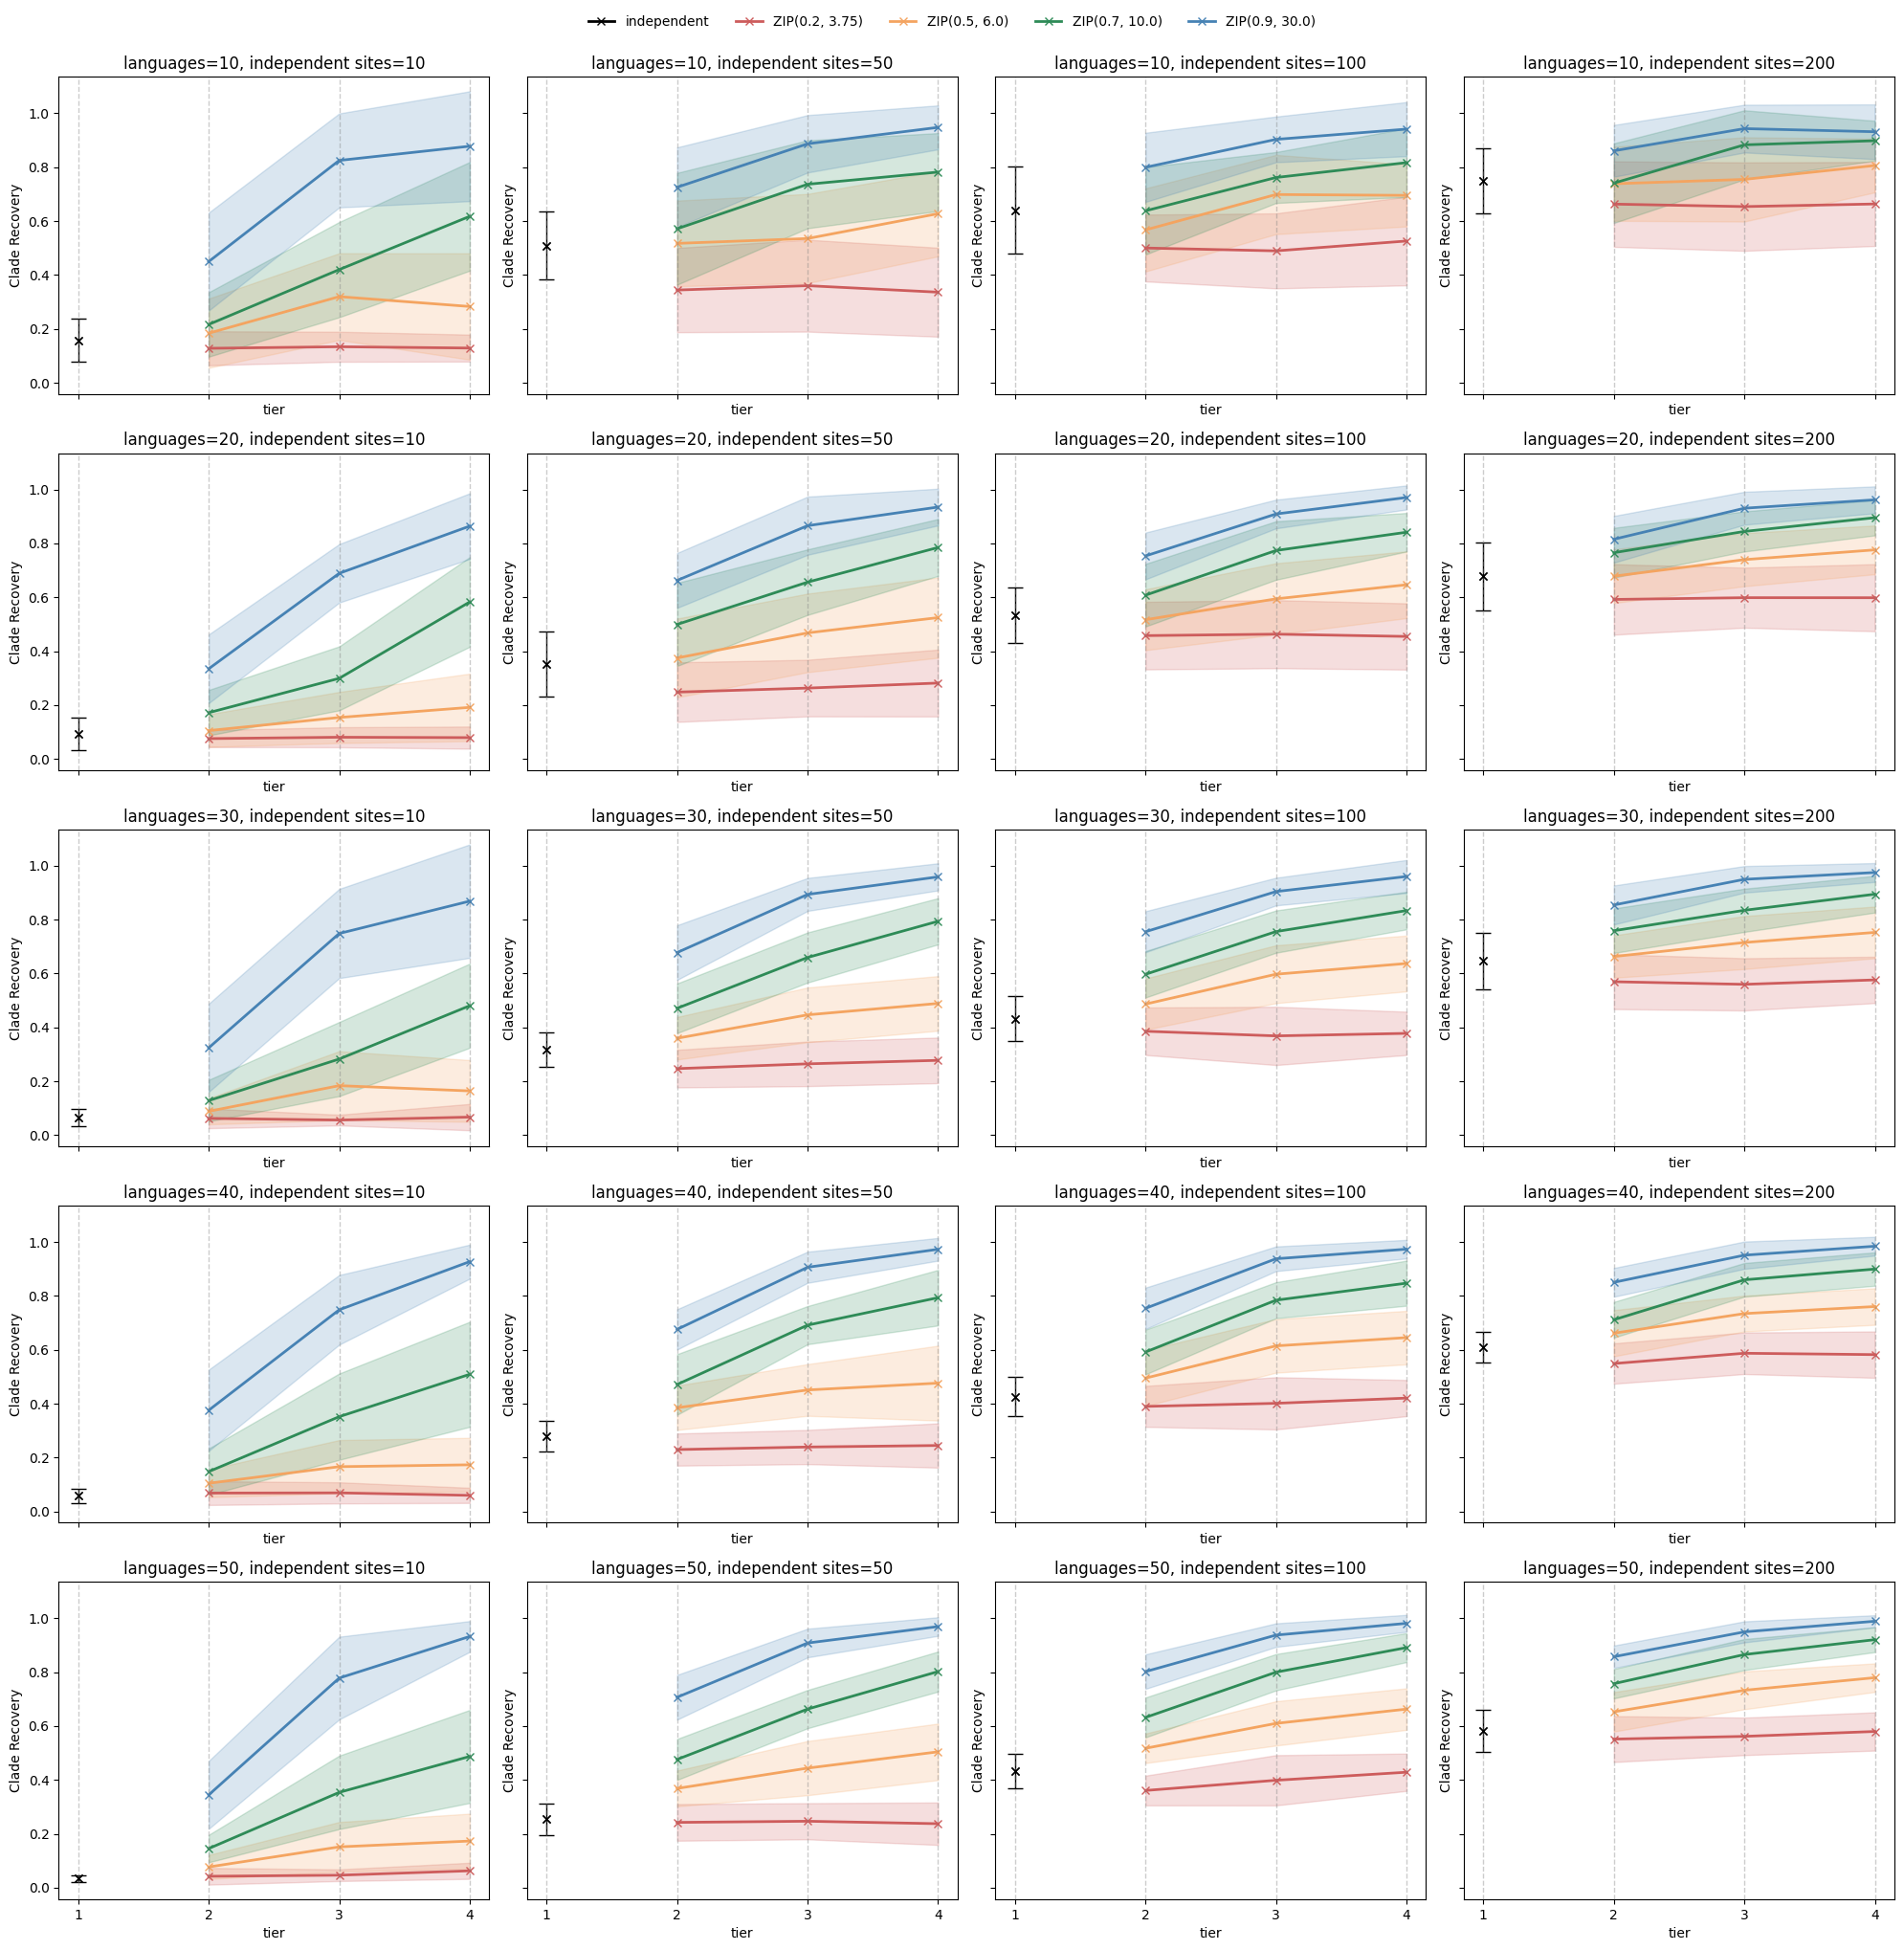

In [5]:
df["tier"] = pd.to_numeric(df["tier"])
df["meanNRF"] = pd.to_numeric(df["meanNRF"])
df["leaves"] = pd.to_numeric(df["leaves"])
df["independent_sites"] = pd.to_numeric(df["independent_sites"])

leaves_vals = sorted(df["leaves"].unique())
sites_vals = sorted(df["independent_sites"].unique())

fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

colors = ["black", "indianred", "sandybrown", "seagreen", "steelblue"]

for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):
        ax = axes[i, j]
        d = df[(df["leaves"] == leaves_val) & (df["independent_sites"] == sites_val)].copy()
        if d.empty:
            ax.set_visible(False)
            continue
        methods = d["ZIP"].unique()
        for k, m in enumerate(methods):
            dm = d[d["ZIP"] == m]
            grouped = dm.groupby("tier")["HighSupportCladesProp"]
            mean = grouped.mean()
            std = grouped.std()
            x = mean.index.values
            color = colors[k]
            ax.plot(x, mean.values, marker="x", color=color, linewidth=2, label=m)
            if m == "independent":
                ax.errorbar(
                    x,
                    mean.values,
                    yerr=std.values,
                    fmt='x',
                    color=color,
                    linewidth=1,
                    capsize=6,
                    capthick=1,
                    label=m
                )
            else:
                ax.fill_between(
                    x,
                    mean - std,
                    mean + std,
                    color=color,
                    alpha=0.2
                )
        ax.set_title(f"languages={leaves_val}, independent sites={sites_val}")
        ax.set_xlabel("tier")
        ax.set_ylabel("Clade Recovery")
        ax.set_xticks([1, 2, 3, 4])
        for x in [1, 2, 3, 4]:
            ax.axvline(x, linestyle="--", linewidth=1, alpha=0.4, color="grey")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles[:-1],
    labels[:-1],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=5,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.tight_layout()
plt.show()

# nRF against Clade Recovery (correlation perhaps?)

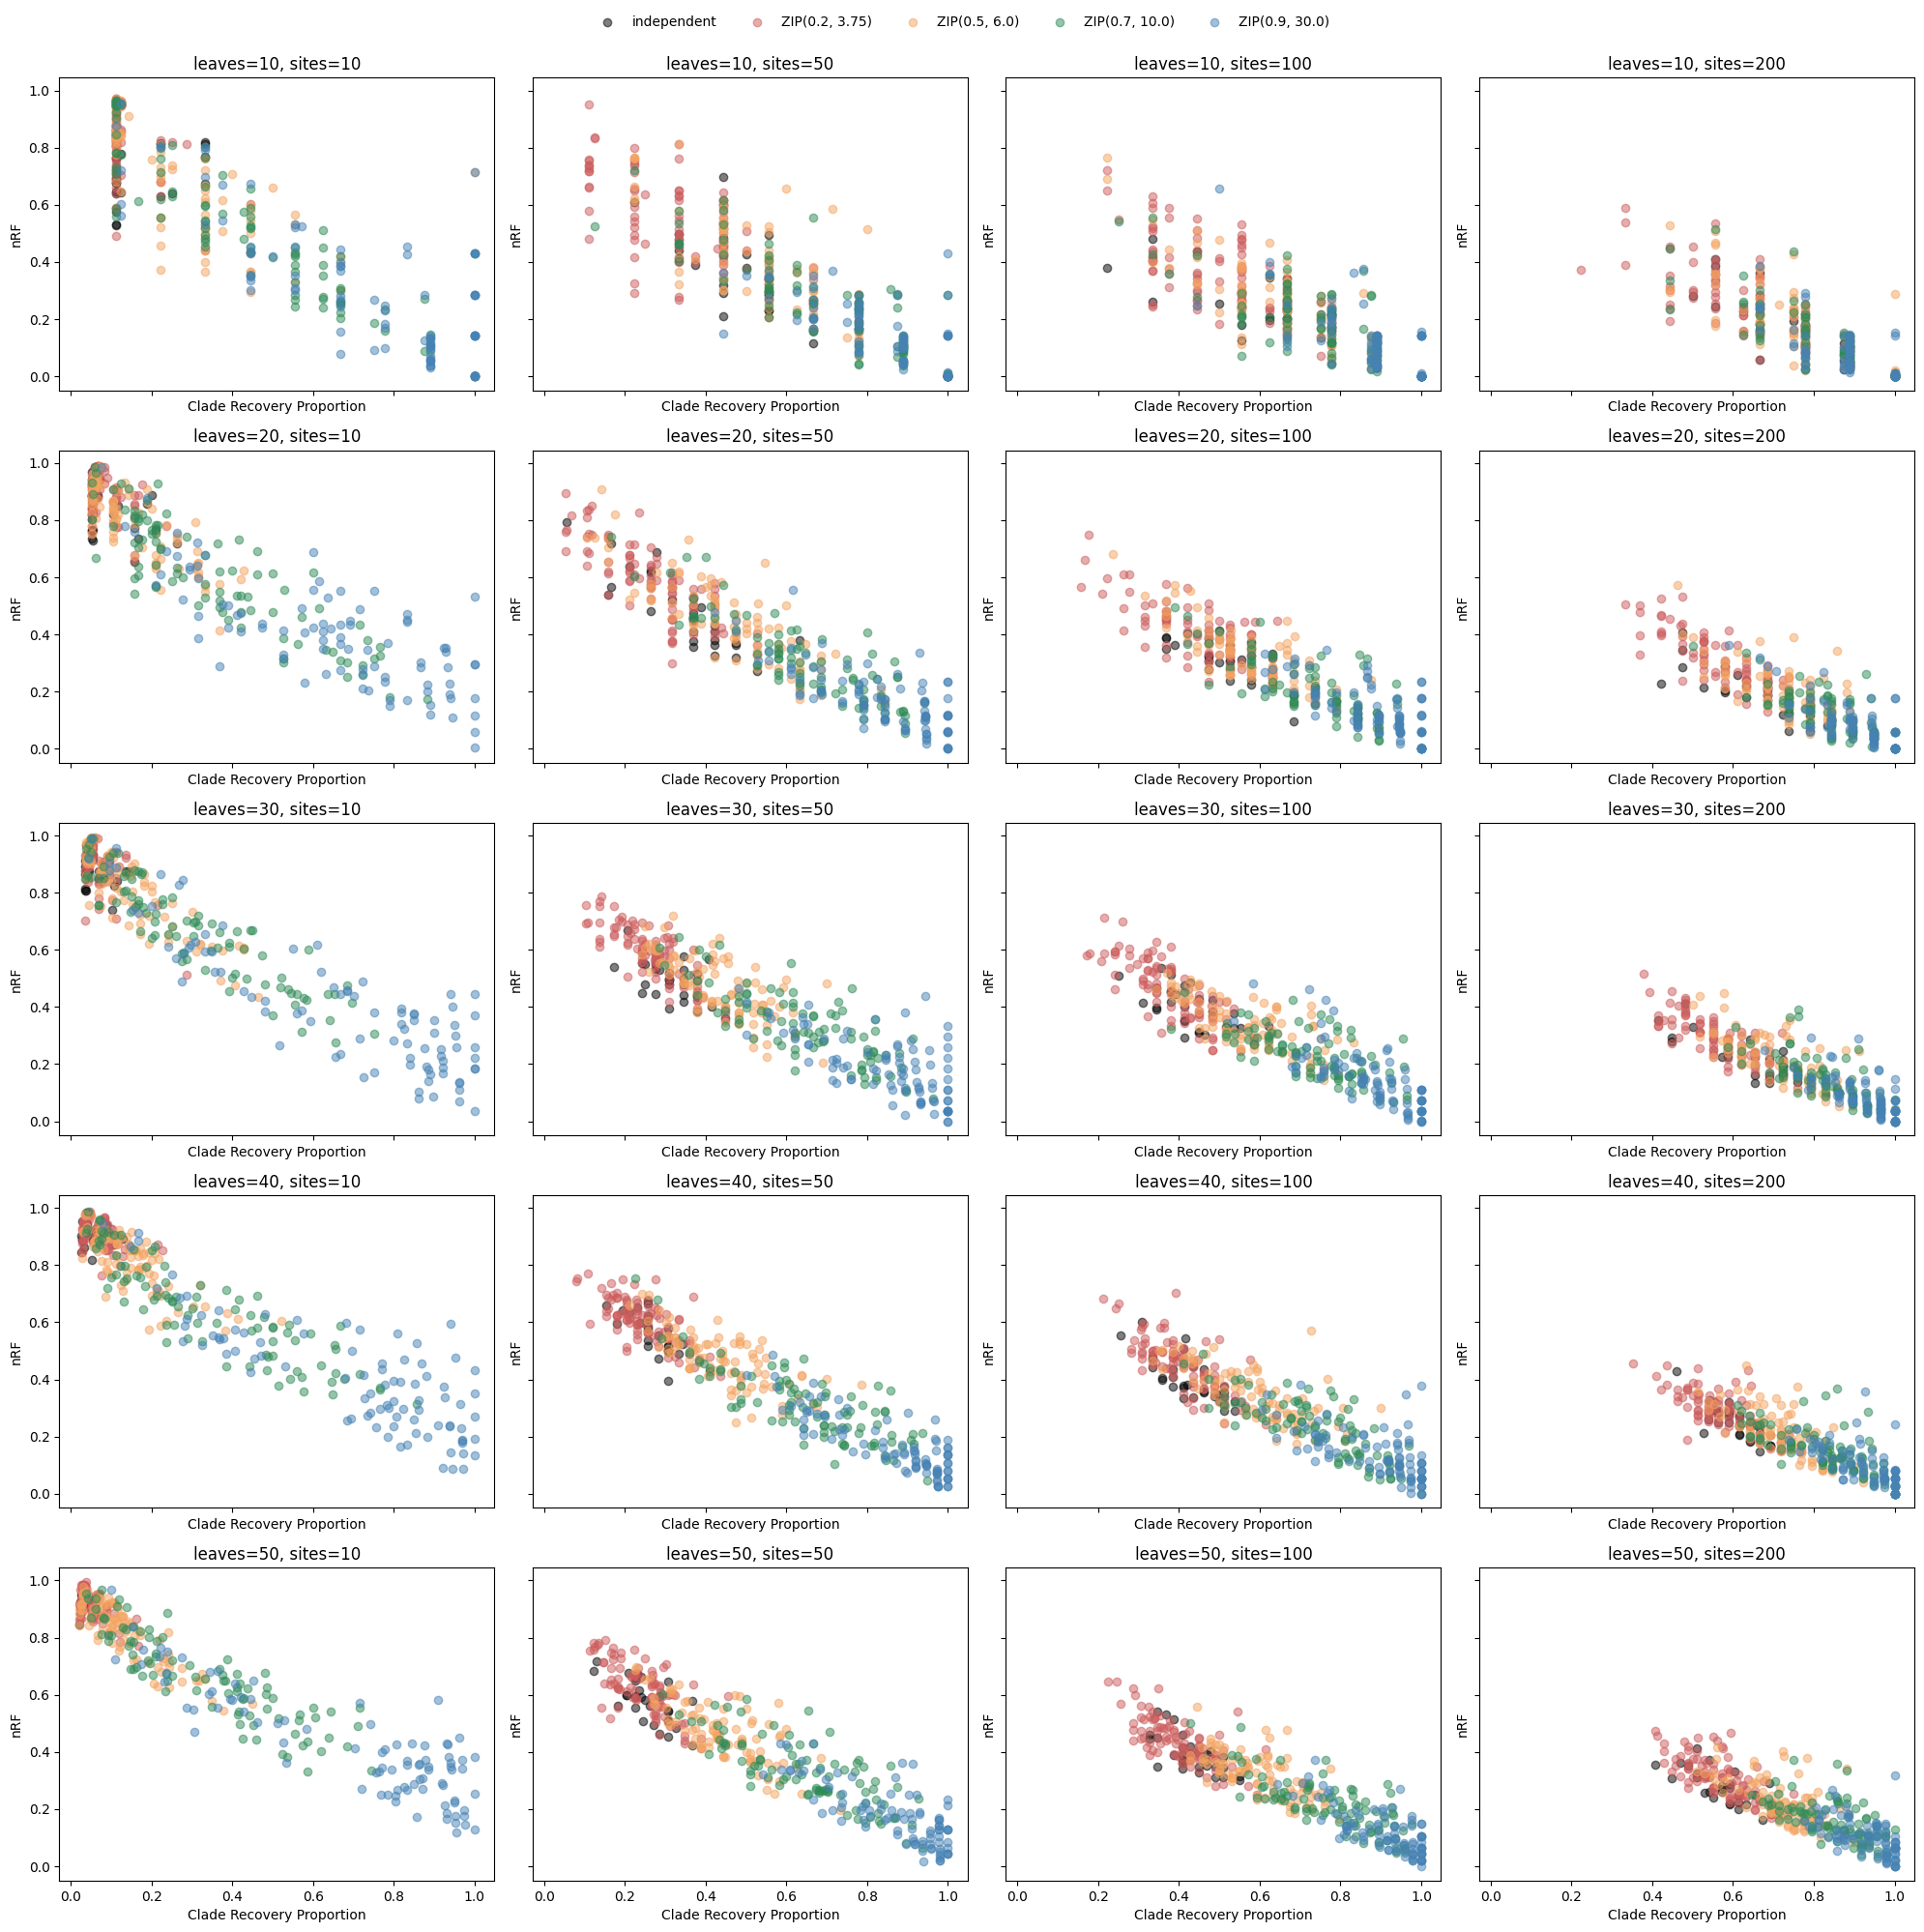

In [6]:
fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):

        ax = axes[i, j]

        d = df[
            (df["leaves"] == leaves_val) &
            (df["independent_sites"] == sites_val)
        ].copy()

        if d.empty:
            ax.set_visible(False)
            continue

        methods = d["ZIP"].unique()

        for k, m in enumerate(methods):
            dm = d[d["ZIP"] == m]

            ax.scatter(
                dm["HighSupportCladesProp"],
                dm["meanNRF"],
                alpha=0.5,
                label=m,
                color=colors[k]
            )

        ax.set_title(f"leaves={leaves_val}, sites={sites_val}")
        ax.set_xlabel("Clade Recovery Proportion")
        ax.set_ylabel("nRF")


handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1),
    ncol=5,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# Tradeoff? not sure how to read this

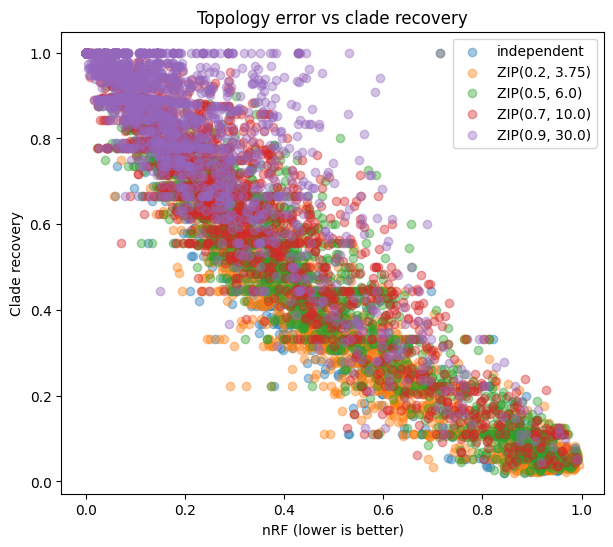

In [7]:
plt.figure(figsize=(7,6))

for m in df["ZIP"].unique():
    d = df[df["ZIP"] == m]

    plt.scatter(
        d["meanNRF"],
        d["HighSupportCladesProp"],
        alpha=0.4,
        label=m
    )

plt.xlabel("nRF (lower is better)")
plt.ylabel("Clade recovery")
plt.title("Topology error vs clade recovery")
plt.legend()
plt.show()

In [8]:
df.groupby(["leaves", "independent_sites", "tier"])[
    ["meanNRF", "HighSupportCladesProp"]
].corr()

meanNRF  \
leaves independent_sites tier                                   
10     10                1    meanNRF                1.000000   
                              HighSupportCladesProp  0.111248   
                         2    meanNRF                1.000000   
                              HighSupportCladesProp -0.838007   
                         3    meanNRF                1.000000   
...                                                       ...   
50     200               2    HighSupportCladesProp -0.890162   
                         3    meanNRF                1.000000   
                              HighSupportCladesProp -0.863666   
                         4    meanNRF                1.000000   
                              HighSupportCladesProp -0.837970   

                                                     HighSupportCladesProp  
leaves independent_sites tier                                               
10     10                1    meanNRF                             0.111248  
                              HighSupportCladesProp               1.000000  
                         2    meanNRF                            -0.838007  
                              HighSupportCladesProp               1.000000  
                         3    meanNRF                            -0.883459  
...                                                                    ...  
50     200               2    HighSupportCladesProp               1.000000  
                         3    meanNRF                            -0.863666  
                              HighSupportCladesProp               1.000000  
                         4    meanNRF                            -0.837970  
                              HighSupportCladesProp               1.000000  

[160 rows x 2 columns]

In [9]:
df

,meanRF,varRF,meanNRF,varNRF,HighSupportCladesProp,likelihoodESS,priorESS,jointESS,tier,ZIP,leaves,independent_sites
0,9.416509,4.567056,0.672608,0.023301,0.333333,8538.954600,7783.763057,7779.632777,1,independent,10,10
1,13.343628,1.409129,0.953116,0.007189,0.111111,8205.016227,5693.185239,5929.639264,2,"ZIP(0.2, 3.75)",10,10
2,11.952228,3.048829,0.853731,0.015555,0.111111,8311.213790,6514.252225,6454.853714,3,"ZIP(0.2, 3.75)",10,10
3,13.141429,1.825440,0.938673,0.009313,0.111111,5669.512310,1229.367300,1237.727957,4,"ZIP(0.2, 3.75)",10,10
4,12.367515,2.370696,0.883394,0.012095,0.111111,8275.715730,6813.695825,6942.392383,2,"ZIP(0.5, 6.0)",10,10
...,...,...,...,...,...,...,...,...,...,...,...,...
7795,20.712810,3.663401,0.220349,0.000415,0.860465,3973.994241,205.855352,3974.323497,3,"ZIP(0.7, 10.0)",50,200
7796,6.219976,1.180939,0.066170,0.000134,0.937500,3218.167665,5267.806025,3263.254780,4,"ZIP(0.7, 10.0)",50,200
7797,8.534385,3.953956,0.090791,0.000447,0.877551,5505.390066,3908.367840,5378.340560,2,"ZIP(0.9, 30.0)",50,200
7798,1.619820,0.615892,0.017232,0.000070,0.979592,4235.842419,7647.920731,4256.636741,3,"ZIP(0.9, 30.0)",50,200


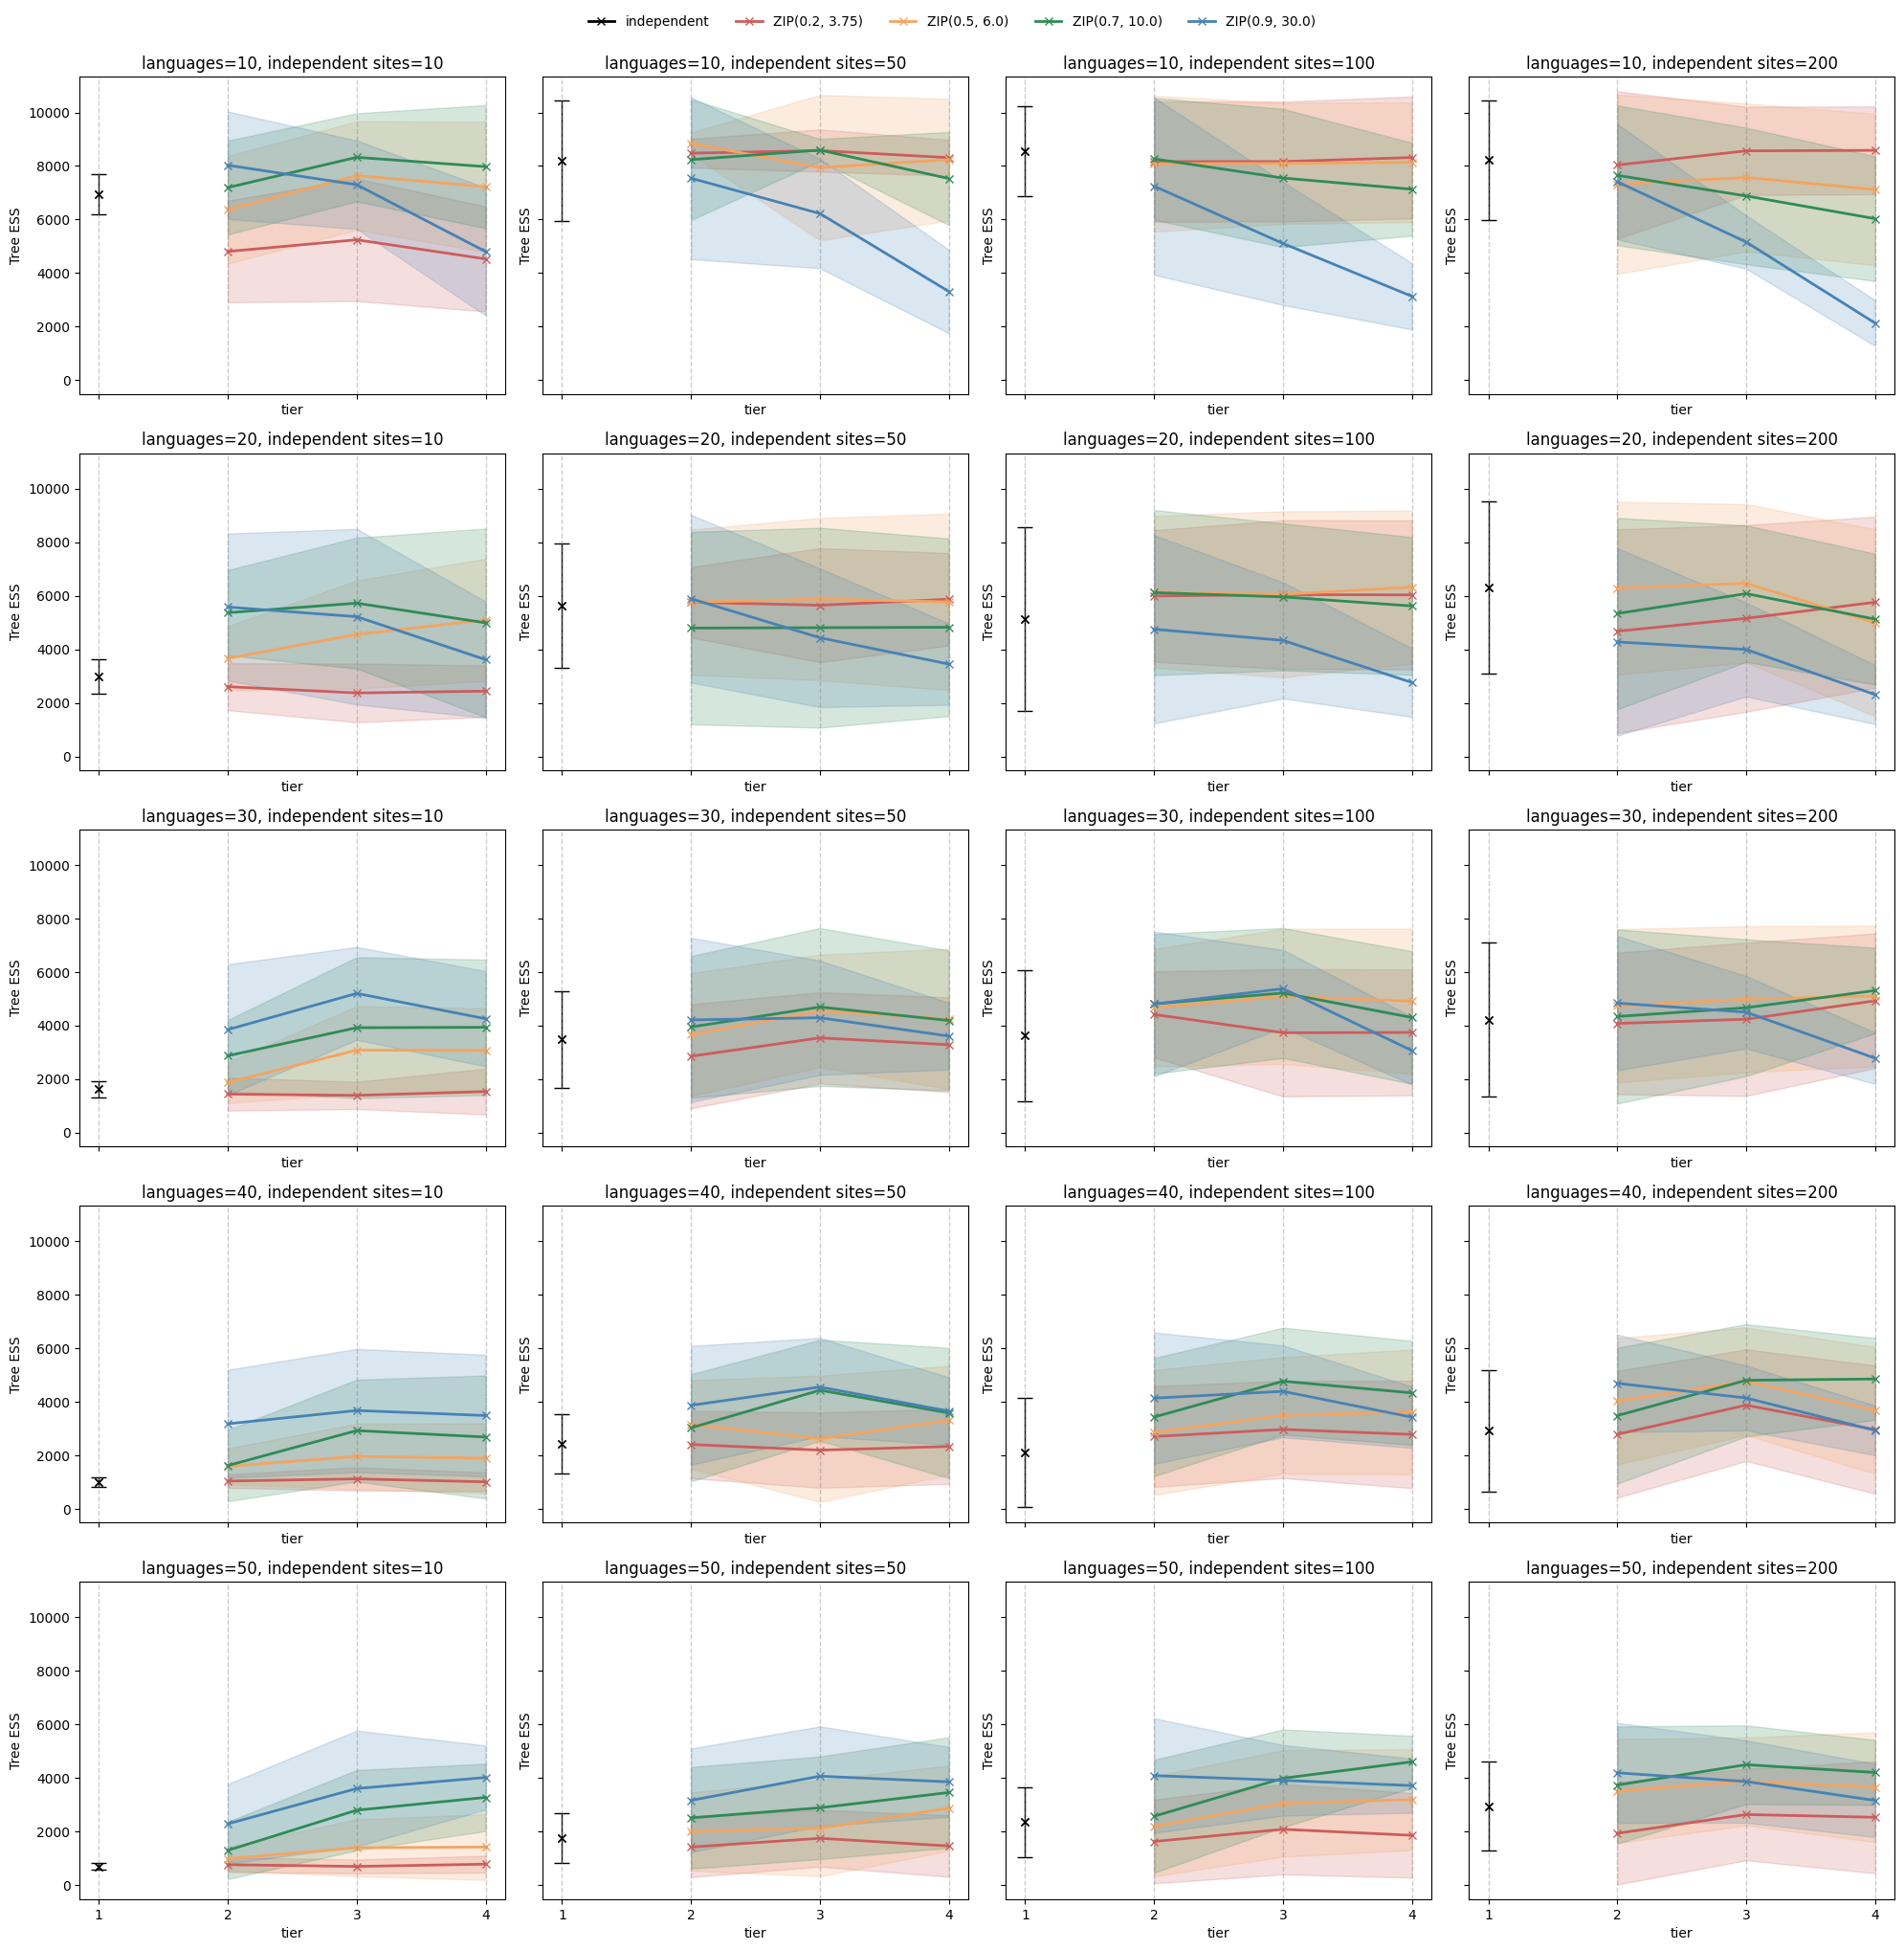

In [10]:
df["tier"] = pd.to_numeric(df["tier"])
df["meanNRF"] = pd.to_numeric(df["meanNRF"])
df["leaves"] = pd.to_numeric(df["leaves"])
df["independent_sites"] = pd.to_numeric(df["independent_sites"])

leaves_vals = sorted(df["leaves"].unique())
sites_vals = sorted(df["independent_sites"].unique())

fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

colors = ["black", "indianred", "sandybrown", "seagreen", "steelblue"]

for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):
        ax = axes[i, j]
        d = df[(df["leaves"] == leaves_val) & (df["independent_sites"] == sites_val)].copy()
        if d.empty:
            ax.set_visible(False)
            continue
        methods = d["ZIP"].unique()
        for k, m in enumerate(methods):
            dm = d[d["ZIP"] == m]
            grouped = dm.groupby("tier")["jointESS"]
            mean = grouped.mean()
            std = grouped.std()
            x = mean.index.values
            color = colors[k]
            ax.plot(x, mean.values, marker="x", color=color, linewidth=2, label=m)
            if m == "independent":
                ax.errorbar(
                    x,
                    mean.values,
                    yerr=std.values,
                    fmt='x',
                    color=color,
                    linewidth=1,
                    capsize=6,
                    capthick=1,
                    label=m
                )
            else:
                ax.fill_between(
                    x,
                    mean - std,
                    mean + std,
                    color=color,
                    alpha=0.2
                )
        ax.set_title(f"languages={leaves_val}, independent sites={sites_val}")
        ax.set_xlabel("tier")
        ax.set_ylabel("Tree ESS")
        ax.set_xticks([1, 2, 3, 4])
        for x in [1, 2, 3, 4]:
            ax.axvline(x, linestyle="--", linewidth=1, alpha=0.4, color="grey")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles[:-1],
    labels[:-1],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=5,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.tight_layout()
plt.show()

In [4]:
thing = [10, 20, 30]
with open(f"something.txt", "w") as f:
            f.write(",".join(map(str, thing)))